In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import glob
import xarray as xr
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.optimize import fsolve, brentq
from process_sumup_cores import def_models
from mo_fit_functions import *

In [3]:
#import cores
cores_df = pd.read_csv("../data/merged/MERGED_CORE_LIST_greenland_2025.csv")

# import fdm reference list
path_to_fdm_locations = "../../reference/FGRN055/"
pointlist_df = pd.read_csv(path_to_fdm_locations+'IN_ll_FGRN055.txt',names=["longitude","latitude","rlat","rlon"],usecols=[0,1,5,6])

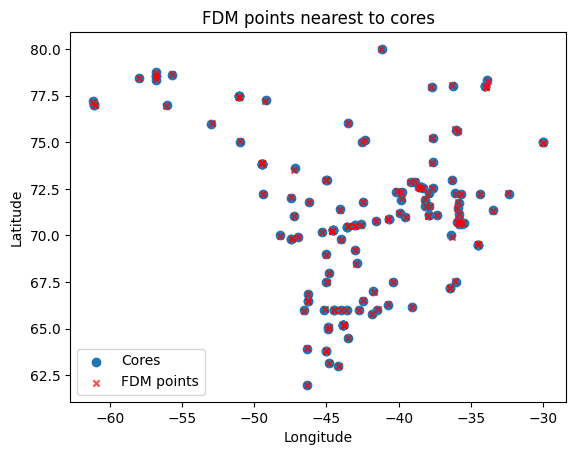

In [4]:
# xs = match_fdm_points_to_cores(core_locations=cores_df[['latitude','longitude']].values,
#                               fdm_pointlist_df=pointlist_df,save_pointlist=True, output_dir="../data/merged/", do_plot=True)

xs = []; distances = []  # distance between the pair of points
save_pointlist=True
output_dir="../data/merged/"
do_plot=True

for point in cores_df[['latitude','longitude']].values:

    assert len(point) == 2, "``points`` should be a tuple or list of tuples (lat, lon)"

    p_lat, p_lon = point
    
    # Find absolute difference between requested point and the grid coordinates.
    abslat = np.abs(pointlist_df.latitude - p_lat)
    abslon = np.abs(pointlist_df.longitude - p_lon)
    
    # Create grid of the maximum values of the two absolute grids
    c = np.maximum(abslon, abslat)

    # Find location where lat/lon minimum absolute value intersects
    x = np.where(c == np.min(c))[0][0]
    xs.append(x)

    # Matched Grid lat/lon
    g_lat = pointlist_df.iloc[x,:].latitude
    g_lon = pointlist_df.iloc[x,:].longitude

    R = 6373.0  # approximate radius of earth in km

    lat1 = np.deg2rad(p_lat); lon1 = np.deg2rad(p_lon)
    lat2 = np.deg2rad(g_lat); lon2 = np.deg2rad(g_lon)
    dlon = lon2 - lon1; dlat = lat2 - lat1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = R * c
    distances.append(distance)

    # #pointlist_df.loc[xs].plot.scatter(x='longitude', y='latitude', title='FDM points nearest to cores', xlabel='Longitude', ylabel='Latitude',figsize=(4,5))

if save_pointlist:
    output_path = f"{output_dir}pointlist_from_cores_tesse_test.csv"
    pointlist_near_cores = pointlist_df.loc[xs].index.values
    np.savetxt(output_path, pointlist_near_cores, fmt='%d')

if do_plot:
        
    fig, ax = plt.subplots()

    ax.scatter(cores_df[['latitude','longitude']].values[:,1], cores_df[['latitude','longitude']].values[:,0], label='Cores')
    pointlist_df.loc[xs].plot.scatter(x='longitude', y='latitude', color='red', marker='x', alpha=0.7, title='FDM points nearest to cores', xlabel='Longitude', ylabel='Latitude',ax=ax, label='FDM points')
    plt.legend()
    
cores_df["FDM_point_index"] = pointlist_df.loc[xs].index.values
cores_df["FDM_latitude"] = pointlist_df.loc[xs].latitude.values
cores_df["FDM_longitude"] = pointlist_df.loc[xs].longitude.values
cores_df["FDM_rlat"] = pointlist_df.loc[xs].rlat.values
cores_df["FDM_rlon"] = pointlist_df.loc[xs].rlon.values
cores_df = cores_df[cores_df['year'] > 1939] # drop all values earlier than the model run starts
cores_df = cores_df[cores_df['year'] < 2024] # drop all values earlier than the model run starts
cores_df = cores_df.reset_index(drop=True)

cores_df["FDM_depth_to_550"] = np.nan
cores_df["FDM_depth_to_830"] = np.nan
cores_df["Fit_R2"] = np.nan
cores_df["Fit_model"] = ""
cores_df["Fit_failed"] = np.nan

pointlist_cores = np.unique(cores_df["FDM_point_index"].values)



In [5]:
project_name = "MO_fit_cores_dpy365"
project_dir = f"/home/nld4814/scratch/{project_name}/"
file_list = [f"/home/nld4814/scratch/{project_name}/output/FGRN055_era055_2D_{str(point)}.nc" for point in pointlist_cores]
#merged_df_era055 = find_FDM_depths(cores_df, file_list, project_dir, target_densities, clean_2D=True, do_plot=do_plot, avg_yearly=True)


In [ ]:
#def find_FDM_depths(merged_df, file_list, project_dir, target_densities, clean_2D=False, do_plot=False, avg_yearly=True):

    
all_depths = {}

models = def_models()

for file_i, file_name in enumerate(file_list):
        
    # load data and find core match
    try:
        data_df = load_2d_file(project_dir, file_name, clean_2D=False)

    # file doesn't exist or is corrupt (former shouldn't happen, latter does occcasionally - need to rerun FDM point if so)    
    except Exception as e:
        print(f"Failed to load file {file_i} - {file_name}: {e}")
        continue

    # find core(s) closest to this fdm point
    core_matches = cores_df[cores_df["FDM_point_index"] == data_df.point_index.values]
    if len(core_matches) == 0:
        print(f"No core match for FDM point {data_df.point_index.values} in file {file_i} - {file_name}")
        continue

    # often more than one core is near the same FDM point
    for core_i in range(len(core_matches)):
            
        core_match = core_matches.iloc[core_i]
        

        data_df_sel = match_core_to_fdm(data_df, core_match, avg_yearly=True) # selects the correct date for each core
            
        density = data_df_sel.dens.values
        depth = data_df_sel.depth.values

        depth_smooth = np.linspace(depth.min(), depth.max(), 200)

        fitted_params = {}

        best_r2 = -np.inf
        best_model = None

        for idx, (func, name, expression, color, func_min) in enumerate(models):


            str_point = str(data_df_sel["point_index"].values)

            try:
                str_core = core_match["core_name"]
                title_core = f'FDM: {str_point} Core: {str_core}'
            except:
                str_core = str(core_match.name)
                title_core = f'FDM: {str_point} Core: {str_core}'

            try:
                # Fit the model
                popt, pcov = curve_fit(func, depth, density)
                    
                # Store parameters with a simple key
                model_name = name.split(":")[0].strip().lower().replace(" ", "_")
                fitted_params[model_name] = popt
  
                # Calculate fitted values
                density_fit = func(depth, *popt)
                density_smooth = func(depth_smooth, *popt)

                # Calculate R²
                residuals = density - density_fit
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((density - np.mean(density))**2)
                r_squared = 1 - (ss_res / ss_tot)

                if r_squared > best_r2:
                    best_r2 = r_squared
                    best_model = (func, popt, name, expression, round(best_r2,3), func_min)
                    
                if do_plot:

                    fig, axes = plt.subplots(figsize=(5, 5))
                            
                    # Plot data and fit (top row)
                    ax1 = axes
                    ax1.scatter(depth, density, alpha=0.6, label='Model', s=30)
                    ax1.plot(depth_smooth, density_smooth, color=color, linewidth=2, label='Fit')
                    ax1.plot(core_match['depth_to_550'], 550, 'm*', label='Core 550 kg/m³', markersize=8)
                    ax1.plot(core_match['depth_to_830'], 830, 'm*', label='Core 830 kg/m³', markersize=8)
                    ax1.set_xlabel('Depth')
                    ax1.set_ylabel('Density')
                    ax1.legend()
                    ax1.grid(True, alpha=0.3)
                    ax1.set_title(f'{title_core}\n{name.split(":")[0]}\nR² = {r_squared:.4f}')
                        
                    #     # Plot residuals (bottom row)
                    #     ax2 = axes[1, idx]
                    #     ax2.scatter(depth, residuals, alpha=0.6, color=color, s=30)
                    #     ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
                    #     ax2.set_xlabel('Depth')
                    #     ax2.set_ylabel('Residuals')
                    #     ax2.grid(True, alpha=0.3)
                    #     ax2.set_title('Residuals')
                    
            except Exception as e:
                print(f"\n{name}: Failed to fit - {e}")
                    
    #         #         if do_plot:
                        
    #         #             fig, ax1 = plt.subplots(1, figsize=(5,5))

    #         #             ax1.scatter(depth, density, alpha=0.6, label='Model', s=30)
    #         #             ax1.plot(core_match['depth_to_550'], 550, 'm*', label='Core 550 kg/m³', markersize=8)
    #         #             ax1.plot(core_match['depth_to_830'], 830, 'm*', label='Core 830 kg/m³', markersize=8)
    #         #             ax1.set_xlabel('Depth')
    #         #             ax1.set_ylabel('Density')
    #         #             ax1.legend()
    #         #             ax1.grid(True, alpha=0.3)
    #         #             ax1.set_title(f'{title_core}')
                    
    #         # if do_plot:
    #         #     plt.tight_layout()
    #         #     plt.show()

    #         target_depths = {}
    #         failed = 0

    #         for rho in target_densities:
    #             #print(f"\nFinding depth for target density: {rho} kg/m³ using a {best_model[2]} fit")

    #             if best_model[4] < 0.9:
    #                 #print(f"R² too low ({best_model[4]}) to reliably estimate depth for density {rho} kg/m³")
    #                 failed = int(1)
    #                 depth_at_rho = np.nan
                
    #             else:

    #                 try: 
    #                     depth_at_rho = brentq(
    #                         best_model[5],
    #                         depth.min(),
    #                         depth.max(),
    #                         args=(*best_model[1], rho)
    #                     )


    #                 except ValueError as e:

    #                     depth_at_rho = np.nan
    #                     failed = int(1)

    #             target_depths[rho] = {"depth":round(depth_at_rho,2), "r2":float(best_model[4]), "model_name":best_model[2], "failed":failed}

    #         if (do_plot) and (failed==0):
                    
    #             fig, ax1 = plt.subplots(1, figsize=(5,5))

    #             ax1.scatter(depth, density, alpha=0.6, color='grey', label='Model', s=30)
    #             ax1.plot(core_match['depth_to_550'], 550, 'm*', label='Core 550 kg/m³', markersize=8)
    #             ax1.plot(core_match['depth_to_830'], 830, 'm*', label='Core 830 kg/m³', markersize=8)
    #             ax1.plot(target_depths[550]["depth"], 550, 'g^', label='Fit 550 kg/m³', markersize=8)
    #             ax1.plot(target_depths[830]["depth"], 830, 'g^', label='Fit 830 kg/m³', markersize=8)
    #             ax1.set_xlabel('Depth')
    #             ax1.set_ylabel('Density')
    #             ax1.legend()
    #             ax1.grid(True, alpha=0.3)
    #             ax1.set_title(f'{title_core}')
                
    #             plt.tight_layout()

    #             plt.save_figure("../figures/")

    #         all_depths[int(core_match.name)] = target_depths


    # # add depths to merged df
    # for i, row_i in enumerate(all_depths):
    #     merged_df.loc[row_i, "FDM_depth_to_550"] = all_depths[row_i][550]["depth"]
    #     merged_df.loc[row_i, "FDM_depth_to_830"] = all_depths[row_i][830]["depth"]
    #     merged_df.loc[row_i, "Fit_R2"] = all_depths[row_i][550]["r2"]
    #     merged_df.loc[row_i, "Fit_model"] = all_depths[row_i][550]["model_name"]
    #     merged_df.loc[row_i, "Fit_failed"] = all_depths[row_i][550]["failed"]

    # #removes all failed or nan fits
    # merged_df = merged_df[merged_df["Fit_failed"]==0]
    # merged_df = merged_df[~merged_df["Fit_failed"].isna()]

    # return merged_df


Power law: Failed to fit - Optimal parameters not found: Number of calls to function has reached maxfev = 800.
Failed to load file 9 - /home/nld4814/scratch/MO_fit_cores_dpy365/output/FGRN055_era055_2D_6410.nc: [Errno 2] No such file or directory: '/home/nld4814/scratch/MO_fit_cores_dpy365/output/FGRN055_era055_2D_6410.nc'

Power law: Failed to fit - Optimal parameters not found: Number of calls to function has reached maxfev = 800.
Failed to load file 34 - /home/nld4814/scratch/MO_fit_cores_dpy365/output/FGRN055_era055_2D_18402.nc: [Errno 2] No such file or directory: '/home/nld4814/scratch/MO_fit_cores_dpy365/output/FGRN055_era055_2D_18402.nc'

Power law: Failed to fit - Optimal parameters not found: Number of calls to function has reached maxfev = 800.
Failed to load file 71 - /home/nld4814/scratch/MO_fit_cores_dpy365/output/FGRN055_era055_2D_25401.nc: [Errno 2] No such file or directory: '/home/nld4814/scratch/MO_fit_cores_dpy365/output/FGRN055_era055_2D_25401.nc'


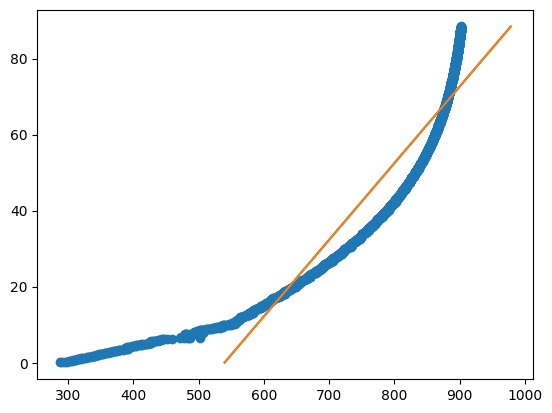

In [16]:
plt.plot(density_fit, depth)
plt.plot(density_smooth, depth_smooth)
plt.scatter(density, depth)



Power law: Failed to fit - Optimal parameters not found: Number of calls to function has reached maxfev = 800.
Logarithmic params: [175.00788332  -1.69796986 286.50542971]
Linear params: [  3.0523486  695.63432735]


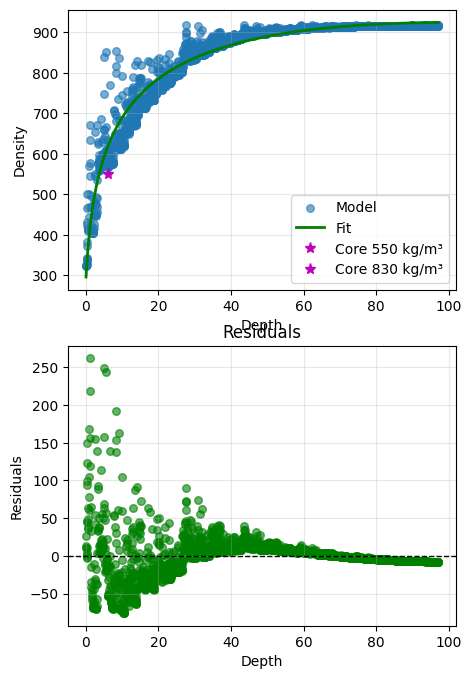

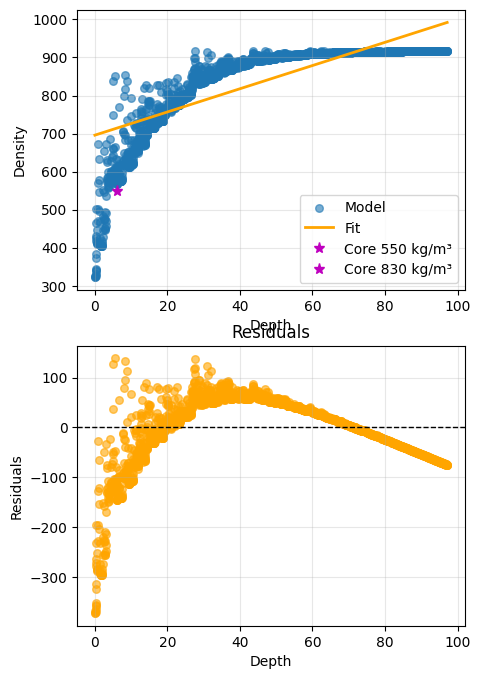

In [17]:
file_name = file_list[0]   # pick first file (or any index you want)

data_df = load_2d_file(project_dir, file_name, clean_2D=False)

core_matches = cores_df[cores_df["FDM_point_index"] == data_df.point_index.values]

# Take just ONE core
core_match = core_matches.iloc[0]

data_df_sel = match_core_to_fdm(data_df, core_match, avg_yearly=True)

density = data_df_sel.dens.values
depth = data_df_sel.depth.values

depth_smooth = np.linspace(depth.min(), depth.max(), 200)

models = def_models()

best_r2 = -np.inf
best_model = None

for func, name, expression, color, func_min in models:
    try:
        popt, _ = curve_fit(func, depth, density)

        density_fit = func(depth, *popt)
        density_smooth = func(depth_smooth, *popt)

        # Calculate R²
        residuals = density - density_fit
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((density - np.mean(density))**2)
        r_squared = 1 - (ss_res / ss_tot)

        if r_squared > best_r2:
            best_r2 = r_squared
            best_model = (func, popt, name, expression, round(best_r2,3), func_min)

        print(f"{name} params:", popt)

        # Plot data and fit (top row)
        fig, axes = plt.subplots(2, 1, figsize=(5, 8))
        ax1 = axes[0]
        ax1.scatter(depth, density, alpha=0.6, label='Model', s=30)
        ax1.plot(depth_smooth, density_smooth, color=color, linewidth=2, label='Fit')
        ax1.plot(core_match['depth_to_550'], 550, 'm*', label='Core 550 kg/m³', markersize=8)
        ax1.plot(core_match['depth_to_830'], 830, 'm*', label='Core 830 kg/m³', markersize=8)
        ax1.set_xlabel('Depth')
        ax1.set_ylabel('Density')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        #ax1.set_title(f'{title_core}\n{name.split(":")[0]}\nR² = {r_squared:.4f}')

        # Plot residuals (bottom row)
        ax2 = axes[1]
        ax2.scatter(depth, residuals, alpha=0.6, color=color, s=30)
        ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
        ax2.set_xlabel('Depth')
        ax2.set_ylabel('Residuals')
        ax2.grid(True, alpha=0.3)
        ax2.set_title('Residuals')

    except Exception as e:
                print(f"\n{name}: Failed to fit - {e}")

In [28]:
target_depths = {}
failed = 0
target_densities = [550,830]
for rho in target_densities:
    print(f"\nFinding depth for target density: {rho} kg/m³ using a {best_model[2]} fit")

    if best_model[4] < 0.9:
        print(f"R² too low ({best_model[4]}) to reliably estimate depth for density {rho} kg/m³")
        failed = int(1)
        depth_at_rho = np.nan
                
    else:

        try: 
            depth_at_rho = brentq(
                best_model[5],
                depth.min(),
                depth.max(),
                args=(*best_model[1], rho)
                )


        except ValueError as e:

            depth_at_rho = np.nan
            failed = int(1)

    target_depths[rho] = {"depth":round(depth_at_rho,2), "r2":float(best_model[4]), "model_name":best_model[2], "failed":failed}



Finding depth for target density: 550 kg/m³ using a Logarithmic fit

Finding depth for target density: 830 kg/m³ using a Logarithmic fit


In [29]:
target_depths

{550: {'depth': 3.67, 'r2': 0.943, 'model_name': 'Logarithmic', 'failed': 0},
 830: {'depth': 28.4, 'r2': 0.943, 'model_name': 'Logarithmic', 'failed': 0}}

In [22]:
best_model

(<function process_sumup_cores.def_models.<locals>.logarithmic(x, a, b, c)>,
 array([175.00788332,  -1.69796986, 286.50542971]),
 'Logarithmic',
 'a*log(x+1) + b*x + c',
 np.float64(0.943),
 <function process_sumup_cores.def_models.<locals>.log_minimization(x, a, b, c, target)>)

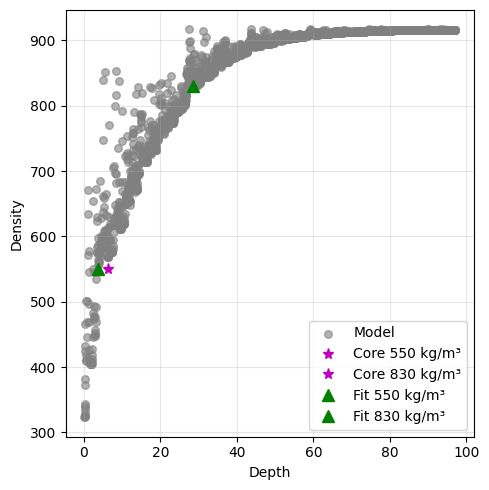

In [31]:
fig, ax1 = plt.subplots(1, figsize=(5,5))
ax1.scatter(depth, density, alpha=0.6, color='grey', label='Model', s=30)
ax1.plot(core_match['depth_to_550'], 550, 'm*', label='Core 550 kg/m³', markersize=8)
ax1.plot(core_match['depth_to_830'], 830, 'm*', label='Core 830 kg/m³', markersize=8)
ax1.plot(target_depths[550]["depth"], 550, 'g^', label='Fit 550 kg/m³', markersize=8)
ax1.plot(target_depths[830]["depth"], 830, 'g^', label='Fit 830 kg/m³', markersize=8)
ax1.set_xlabel('Depth')
ax1.set_ylabel('Density')
ax1.legend()
ax1.grid(True, alpha=0.3)

                
plt.tight_layout()